# Data Provenance and Measurement Audit of the UCI Bike Sharing Dataset

DS-A1 | Descriptive, observational associations | Official UCI archive

This notebook evaluates data suitability before interpretation. All numeric findings are computed below and saved in machine-readable files. No raw observations are deleted or imputed. See the final computed takeaways for the audit and analytical findings.

## 1. Introduction
### 1.1 Research Question
How does hourly bike rental volume vary with weather conditions, working-day status, and hour of day in the 2011–2012 Capital Bikeshare data?
### 1.2 Stakeholder
Capital Bikeshare operations and planning team, using historical patterns as an operating-analysis reference. The data do not directly identify optimal dispatch.
### 1.3 Population
Capital Bikeshare system-hours during the 2011–2012 observation period that the dataset is intended to represent.
### 1.4 Sample
The actual hourly observations in `hour.csv`. The exact row count is calculated after loading.
### 1.5 Unit of Analysis
One Capital Bikeshare system-hour: one date and recorded clock hour.
### 1.6 Target
`cnt`, the total rental count including `casual` and `registered`; the identity is tested below.
### 1.7 Estimand
The conditional mean hourly rental count across weather conditions, working-day status, and hour of day within the observed 2011–2012 Capital Bikeshare period:
$$E[\mathrm{cnt}\mid\mathrm{weathersit},\mathrm{workingday},\mathrm{hr}].$$
This is an associational estimand among observed system-hours. Unobserved combinations do not have an estimated mean.
### 1.8 Scope and Boundary
No weather causal effects, universal city comparisons, 2026 extrapolation, complex prediction models or perfect latent-demand measurement are claimed. Missing rows can restrict population coverage.

### Key Assumptions
Counts refer to recorded system-hours. Calendar parsing is reliable; weekday encoding must be investigated because official definitions omit its mapping. The nominal 24-hour grid is an audit device rather than a timezone-resolved exposure measure. Bootstrap intervals require approximate temporal-resampling assumptions, not random sampling from all cities.

### Setup and immutable input verification

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
pd.set_option('display.max_colwidth', None)
ROOT = Path.cwd().resolve()
if not (ROOT / "data/raw/hour.csv").exists():
    ROOT = ROOT.parent
assert (ROOT / "scripts/analysis.py").exists(), "Execute from project root or notebooks directory"
sys.path.insert(0, str(ROOT / "scripts"))
import analysis as a
RANDOM_SEED = 42
assert a.RANDOM_SEED == RANDOM_SEED
df, day, metadata, dictionary = a.load_data()
print(f"Sample: {len(df):,} system-hours; {len(df.columns)} raw columns; {len(day)} daily rows")
display(df.head(5))

PASS: all pinned source hashes and sizes verified.
Sample: 17,379 system-hours; 17 raw columns; 731 daily rows


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Dataset Provenance
The original source is Capital Bikeshare's 2011–2012 historical transaction log. Hadi Fanaee-T / LIAAD aggregated hourly and daily counts and added Freemeteo weather and calendar information, according to the archived README. UCI publishes the archive. This project uses the downloaded ZIP and unchanged extracted files, identified by SHA-256.

Original feeds, exact exclusions, weather alignment, timezone and daylight-saving handling have not been independently reconstructed. Official-page and archive disagreements are audit findings, not silently reconciled definitions.

Source: [UCI Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset). Dataset citation: Fanaee-T (2013), [DOI 10.24432/C5W894](https://doi.org/10.24432/C5W894). License: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), independently checked in the saved official-page HTML. Archive README requests attribution to Fanaee-T and Gama (2013), [paper DOI 10.1007/s13748-013-0040-3](https://doi.org/10.1007/s13748-013-0040-3).

In [2]:
display(Markdown(f"**Downloaded:** {metadata['download_datetime_utc']}  \n**Observed dates:** {metadata['observation_start']} to {metadata['observation_end']}  \n**Creator:** {metadata['creator']}  \n**Repository:** {metadata['repository']}  \n**DOI:** {metadata['doi']}  \n**License:** {metadata['license']}"))
display(pd.DataFrame(metadata['files']).T[['size_bytes', 'sha256']])

**Downloaded:** 2026-09-30T02:16:41.598381+00:00  
**Observed dates:** 2011-01-01 to 2012-12-31  
**Creator:** Hadi Fanaee-T  
**Repository:** UCI Machine Learning Repository  
**DOI:** 10.24432/C5W894  
**License:** CC BY 4.0

,size_bytes,sha256
hour.csv,1156736,e03de4ee4ef4dc376ac6e04bf829673c6269e8eba5c60fa121640fa2f829504f
day.csv,57569,a6bcf826782d3c0fbfdcbeead17cd0884185a0dafe8ff10cd48a874ee7ba18be
Readme.txt,5607,b92c8628622948bf0828c43a1b315d1517c3d7fd63654730d0dea379b8e88175
Bike-Sharing-Dataset.zip,279992,b70182d0d0508e9abbb79306ce5c0cec34869000f8220175ac83d11dbe845401
uci_official_page.html,157041,25386f08f920472c16f8973d5c51e390abf546d42c3e9cc3c82cb497311eecdb


## 3. Data-generating Process
The lineage distinguishes documented aggregation from possible measurement mechanisms. Realized rentals may differ from latent demand. Supply constraints in the diagram are conceptual; these files do not establish that they occurred.

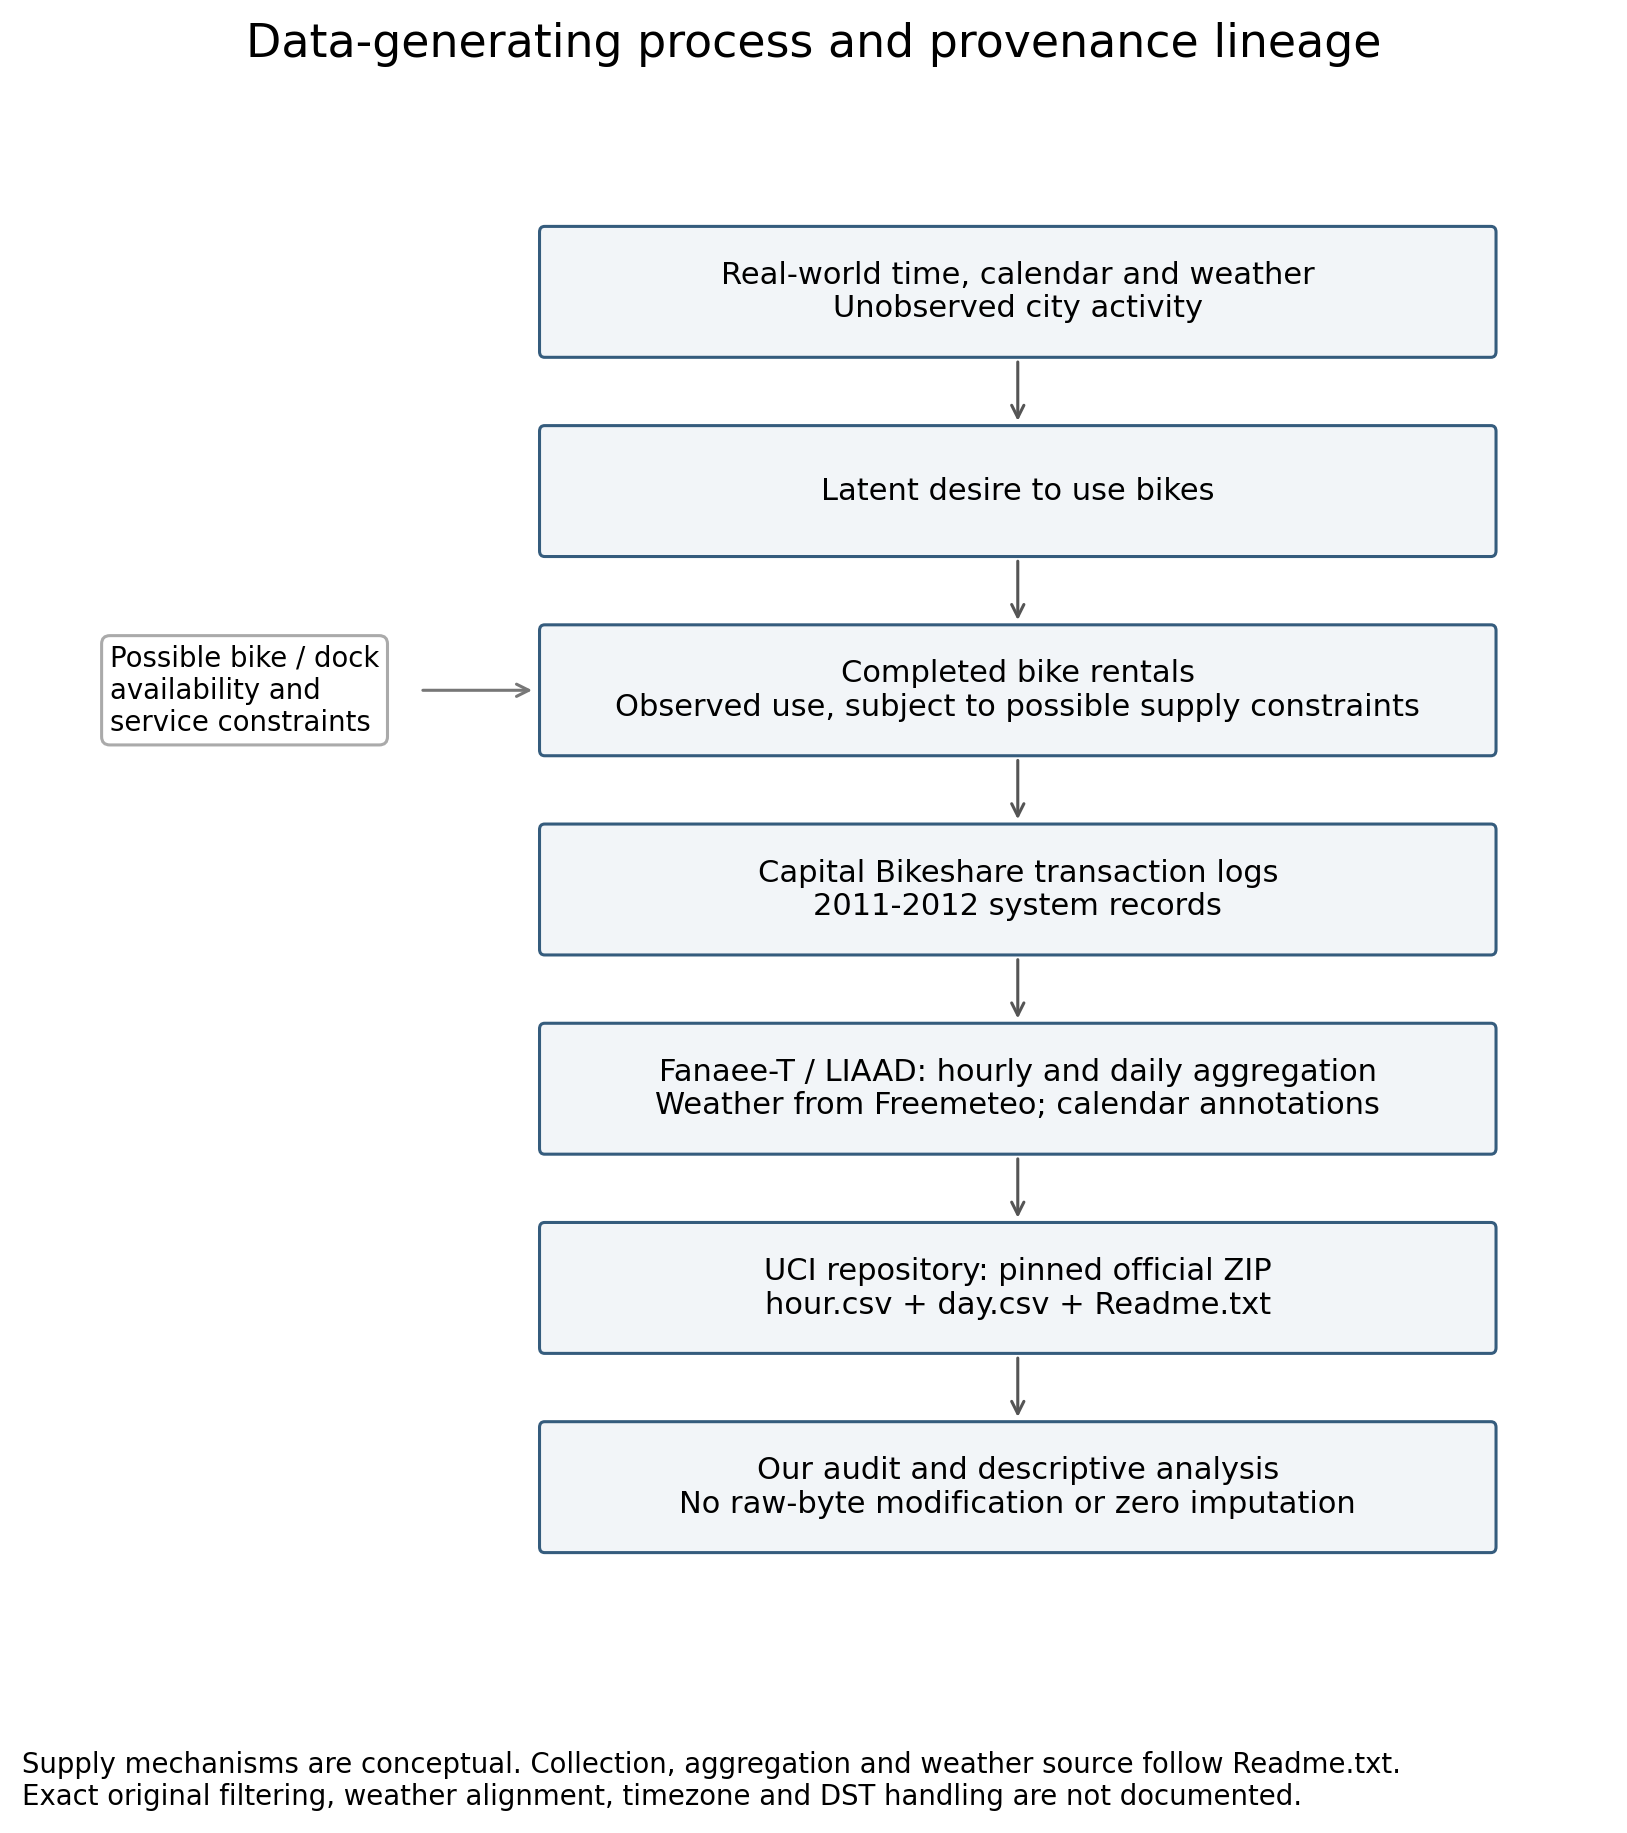

In [3]:
a.dgp_figure()
display(Image(filename=str(ROOT / 'results/figures/00_dgp_lineage.png'), width=760))

## 4. Schema, Range, Missingness and Duplicate Audit
Audit definitions are documented in `docs/data_dictionary.csv` and implemented in `scripts/analysis.py`. All fields are checked; counts have no invented maximum. Zero boundary values are inspected separately from true nulls. Exact and date-hour semantic duplicates are both checked. Failed range samples are saved, not erased.

In [4]:
summary, audit_results = a.audit(df, day, metadata, dictionary)
display(pd.Series(summary).drop(['weekday_mapping_evidence','zero_counts','source_document_conflicts']))
display(audit_results.query("check_category == 'range'")[['variable','expected','status','invalid_row_count']])

row_count                        17379
column_count                        17
day_row_count                      731
missing_cells                        0
exact_duplicates                     0
semantic_duplicates                  0
range_check_failures                 0
range_invalid_rows_total             0
cnt_identity_satisfied           17379
cnt_identity_failures                0
internal_consistency_failures        0
target_leakage_detected           True
nominal_hours                    17544
absent_nominal_hours               165
observed_days                      731
retained_rows                    17379
audit_check_count                   99
dtype: object

,variable,expected,status,invalid_row_count
6,instant,finite positive integer,PASS,0
8,dteday,dteday parseable and in documented 2011-2012 period,PASS,0
10,season,"in [1, 2, 3, 4]; integer",PASS,0
12,yr,"in [0, 1]; integer",PASS,0
14,mnth,"in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]; integer",PASS,0
16,hr,"in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]; integer",PASS,0
18,holiday,"in [0, 1]; integer",PASS,0
20,weekday,"in [0, 1, 2, 3, 4, 5, 6]; integer",PASS,0
22,workingday,"in [0, 1]; integer",PASS,0
24,weathersit,"in [1, 2, 3, 4]; integer",PASS,0


### Missingness and key completeness

In [5]:
display(df.isna().sum().rename('missing_cells').to_frame())
display(pd.read_csv(ROOT / 'results/missingness.csv'))
display(audit_results.query("check_category in ['duplicates','coverage','provenance']")[['check_name','observed','status','notes']])
print('All raw rows retained:', len(df) == summary['retained_rows'])

,missing_cells
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


,variable,missing_cells,blank_strings,suspected_sentinel_count
0,instant,0,0,0
1,dteday,0,0,0
2,season,0,0,0
3,yr,0,0,0
4,mnth,0,0,0
5,hr,0,0,0
6,holiday,0,0,0
7,weekday,0,0,0
8,workingday,0,0,0
9,weathersit,0,0,0


,check_name,observed,status,notes
74,exact_rows,0,PASS,
75,system_hour_key,0,PASS,
76,index_key,0,PASS,
84,nominal_hour_grid,17544 nominal; 165 absent,WARN,Nominal clock grid only; timezone/DST and omission mechanism undocumented. Do not insert zero counts.
85,official_row_count_conflict,CSV=17379; current UCI page=17389,WARN,Archive README count matches CSV; analysis uses actual bytes.
86,definition_conflict,season labels and temperature normalization disagree,WARN,Use numeric season codes and normalized temperatures.


All raw rows retained: True


## 5. Internal Consistency
Test the count identity, parsed year/month, working-day rule, empirical weekday mapping, record-index sequence and daily/hourly rental totals. Neither source specifies weekday code mapping; all cyclic candidates are tested rather than guessing a documented mapping. Working-day consistency uses calendar weekdays directly.

In [6]:
display(audit_results.query("check_category == 'consistency'")[['check_name','observed','status','notes']])
display(pd.Series(summary['weekday_mapping_evidence'],name='mismatches_by_offset'))
assert (df.cnt == df.casual + df.registered).all()

,check_name,observed,status,notes
77,cnt_identity,17379 valid; 0 invalid,PASS,
78,month_identity,17379 valid; 0 invalid,PASS,
79,year_identity,17379 valid; 0 invalid,PASS,
80,weekday_empirical,17379 valid; 0 invalid,PASS,"Neither official document specifies mapping; all seven offsets tested. Empirical consistency, not independently documented encoding."
81,workingday_identity,17379 valid; 0 invalid,PASS,
82,index_sequence,17379 valid; 0 invalid,PASS,"Empirical sequence expectation, not a source-specified maximum."
83,day_hour_counts,0,PASS,


0    17379
1        0
2    17379
3    17379
4    17379
5    17379
6    17379
Name: mismatches_by_offset, dtype: int64

## 6. Leakage Audit
If `cnt` is a prediction target, `casual` and `registered` are deterministic target leakage because they sum to the target. They must be excluded from predictors. The identifier `instant` is not a meaningful deployable feature. Random temporal splits and same-hour observed weather require separate timing review. The current task is descriptive and trains no model.

In [7]:
display(audit_results.query("check_category == 'leakage'")[['check_name','observed','status','notes']])
predictor_candidates = [c for c in df.columns if c not in ['cnt','casual','registered','instant','dteday']]
print('Descriptive calendar/weather candidates:', predictor_candidates)

,check_name,observed,status,notes
87,deterministic_target_components,identity holds on 17379/17379 rows,DETECTED,Outcome components reveal target; leakage is not a corrupted-data range failure.
88,temporal_split,not trained; dates parsed and ordered,REVIEWED,Random splits permit future-period information. Fit preprocessing only within training period; exclude record index.
89,post_outcome_availability,feature publication timestamps not supplied,UNVERIFIABLE,Same-hour realized weather may be unavailable for advance forecasts; no claim of forecast readiness.
90,predictor_review,"exclude cnt,casual,registered,instant",REVIEWED,Other deterministic outcome leakage not found in remaining definitions; timing cannot be verified.


Descriptive calendar/weather candidates: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


## 7. Anomaly Audit
IQR flags are statistical flags, not confirmed errors. Inspect quantiles, histograms, boxplots, largest counts and zero counts. Possible calendar/weather contexts are examined without attributing extreme counts to an unverified event. All observations remain in the main analysis.

In [8]:
descriptive = a.describe(df)
display(descriptive.round(3))
display(pd.read_csv(ROOT / 'results/anomaly_flags.csv').round(3))
display(df.nlargest(10, 'cnt')[['dteday','hr','workingday','season','weathersit','cnt','casual','registered']])
display(df.loc[df.cnt.eq(0)])

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
variable,,,,,,,,,,,,
cnt,17379.0,189.463,181.388,1.00,2.000,5.000,40.000,142.000,281.000,563.100,782.220,977.000
casual,17379.0,35.676,49.305,0.00,0.000,0.000,4.000,17.000,48.000,138.100,240.000,367.000
registered,17379.0,153.787,151.357,0.00,1.000,4.000,34.000,115.000,220.000,465.000,699.220,886.000
temp,17379.0,0.497,0.193,0.02,0.120,0.200,0.340,0.500,0.660,0.800,0.884,1.000
atemp,17379.0,0.476,0.172,0.00,0.121,0.212,0.333,0.485,0.621,0.742,0.818,1.000
hum,17379.0,0.627,0.193,0.00,0.230,0.310,0.480,0.630,0.780,0.930,1.000,1.000
windspeed,17379.0,0.190,0.122,0.00,0.000,0.000,0.104,0.194,0.254,0.418,0.522,0.851


,variable,lower_fence,upper_fence,flagged_rows,zero_rows
0,cnt,-321.500,642.500,505,0
1,casual,-62.000,114.000,1192,1581
2,registered,-245.000,499.000,680,24
3,temp,-0.140,1.140,0,0
4,atemp,-0.099,1.053,0,2
5,hum,0.030,1.230,22,22
6,windspeed,-0.119,0.478,342,2180


,dteday,hr,workingday,season,weathersit,cnt,casual,registered
14773,2012-09-12,18,1,3,1,977,91,886
14964,2012-09-20,17,1,3,1,976,91,885
14748,2012-09-11,17,1,3,1,970,168,802
14725,2012-09-10,18,1,3,1,968,111,857
15084,2012-09-25,17,1,4,1,967,107,860
15780,2012-10-24,17,1,4,1,963,87,876
10622,2012-03-23,17,1,2,2,957,264,693
15108,2012-09-26,17,1,4,1,953,77,876
15444,2012-10-10,17,1,4,1,948,91,857
15588,2012-10-16,17,1,4,1,943,104,839


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


## 8. Transparent Statistical Summaries
Group means, medians, SD and observed support are computed for weather, working-day status, hour, hour x workingday and the complete observed weather x workingday x hour cells. This directly estimates the stated conditional mean; marginal plots are supplementary.

Use 2,000 seeded circular moving-block resamples of seven consecutive calendar days, then recompute rental-sum / observed-hour-count ratios. This preserves within-block dependence and observed-hour weighting. Pointwise percentile 95% intervals describe temporal resampling stability of observed-period summaries. Exact finite-period descriptive means do not require sampling intervals. The bootstrap assumes approximate stability and does not fully preserve seasonality or system growth. One-day cluster intervals are saved as a sensitivity comparison. Withhold intervals below 10 observed dates or insufficient finite resamples. No causal test or external-population confidence is implied.

In [9]:
tables, workingday_difference = a.inference(df)
display(tables['weather'].round(3))
display(tables['workingday'].round(3))
display(pd.Series(workingday_difference))
display(tables['hour'].round(3))
print('Observed conditional cells:', len(tables['conditional']))
display(tables['conditional'].head(12).round(3))

,weathersit,n,mean,median,sd,n_days,ci_low,ci_high,valid_bootstrap_draws,ci_status
0,1,11413,204.869,159.0,189.488,700,189.811,219.074,2000,available
1,2,4544,175.165,133.0,165.432,567,160.726,190.012,2000,available
2,3,1419,111.579,63.0,133.781,300,97.609,127.194,2000,available
3,4,3,74.333,36.0,77.925,3,NaN,NaN,1896,withheld: fewer than 10 observed days


,workingday,n,mean,median,sd,n_days,ci_low,ci_high,valid_bootstrap_draws,ci_status
0,0,5514,181.405,119.0,172.854,231,165.199,196.284,2000,available
1,1,11865,193.208,151.0,185.107,500,179.238,206.729,2000,available


contrast           workingday=1 minus workingday=0
mean_difference                          11.802422
ci_low                                    3.375647
ci_high                                  19.908841
bootstrap_draws                               2000
block_days                                       7
dtype: object

,hr,n,mean,median,sd,n_days,ci_low,ci_high,valid_bootstrap_draws,ci_status
0,0,726,53.898,40.0,42.308,726,49.410,58.455,2000,available
1,1,724,33.376,20.0,33.539,724,30.662,35.953,2000,available
2,2,715,22.870,11.0,26.579,715,21.097,24.634,2000,available
3,3,697,11.727,6.0,13.239,697,10.884,12.612,2000,available
4,4,697,6.353,6.0,4.144,697,5.864,6.831,2000,available
5,5,717,19.890,19.0,13.201,717,18.176,21.561,2000,available
6,6,725,76.044,76.0,55.084,725,69.634,82.023,2000,available
7,7,727,212.065,208.0,161.442,727,194.318,229.609,2000,available
8,8,727,359.011,385.0,235.189,727,332.034,384.254,2000,available
9,9,727,219.309,216.0,93.703,727,204.228,233.637,2000,available


Observed conditional cells: 147


,weathersit,workingday,hr,n,mean,median,sd,n_days,ci_low,ci_high,valid_bootstrap_draws,ci_status
0,1,0,0,162,97.957,97.0,49.427,162,88.256,107.338,2000,available
1,1,0,1,149,72.255,72.0,36.355,149,65.240,79.204,2000,available
2,1,0,2,149,53.128,56.0,25.758,149,48.033,57.963,2000,available
3,1,0,3,148,26.061,26.0,14.299,148,23.427,28.681,2000,available
4,1,0,4,150,8.307,8.0,5.051,150,7.396,9.200,2000,available
5,1,0,5,152,9.572,8.0,7.154,152,8.421,10.797,2000,available
6,1,0,6,148,20.750,19.0,16.878,148,17.970,23.791,2000,available
7,1,0,7,156,48.744,43.0,41.592,156,42.027,56.832,2000,available
8,1,0,8,160,111.975,107.0,68.339,160,99.585,125.161,2000,available
9,1,0,9,160,184.519,183.5,93.698,160,165.298,203.558,2000,available


## 9. Exploratory Analysis
Axes use completed rentals per system-hour; weather definitions are composite categories. Missing weather-hour combinations remain blank. No plot implies causation.

In [10]:
a.figures(df, tables)
computed_findings = a.findings(df, summary, tables, workingday_difference)
text = a.write_docs(df, metadata, computed_findings)

### Figure 1. Count distribution

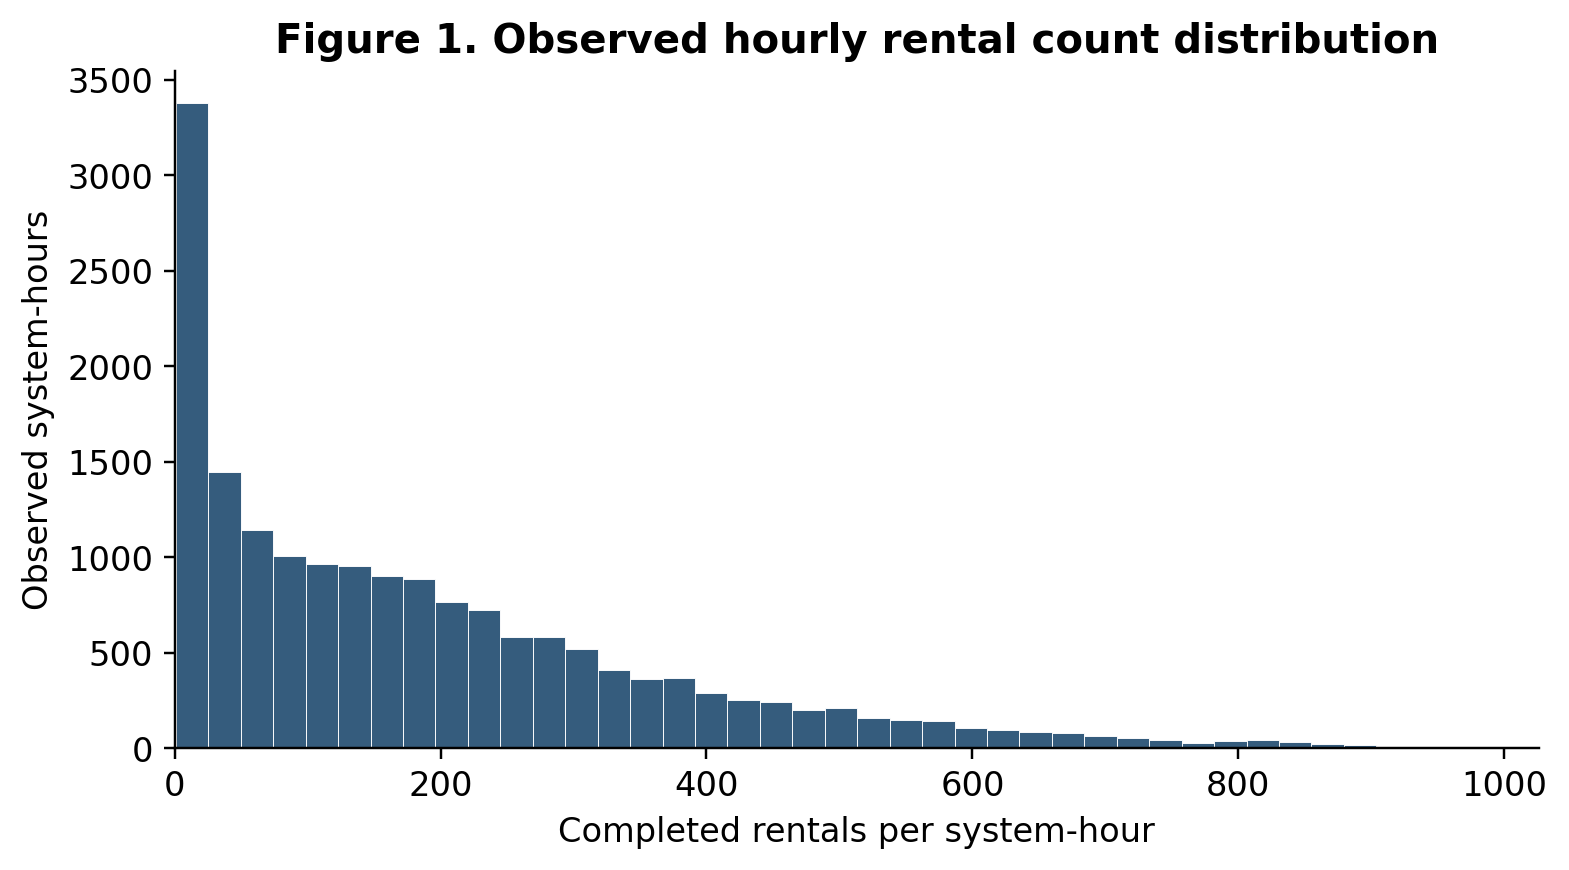

The observed count range is retained in full. Zero-count rows: 0; zero-humidity rows: 22; zero-wind rows: 2180. Zero humidity is a possible measurement concern, not an established missing code. IQR flags and the top 20 counts are saved with calendar/weather context. Statistically extreme rental counts are not automatically treated as data errors because they may represent genuine peak-demand periods.

In [11]:
display(Image(filename=str(ROOT / 'results/figures/01_count_distribution.png'), width=820))
display(Markdown(text['anomaly']))

### Figure 2. Hourly working-day profiles

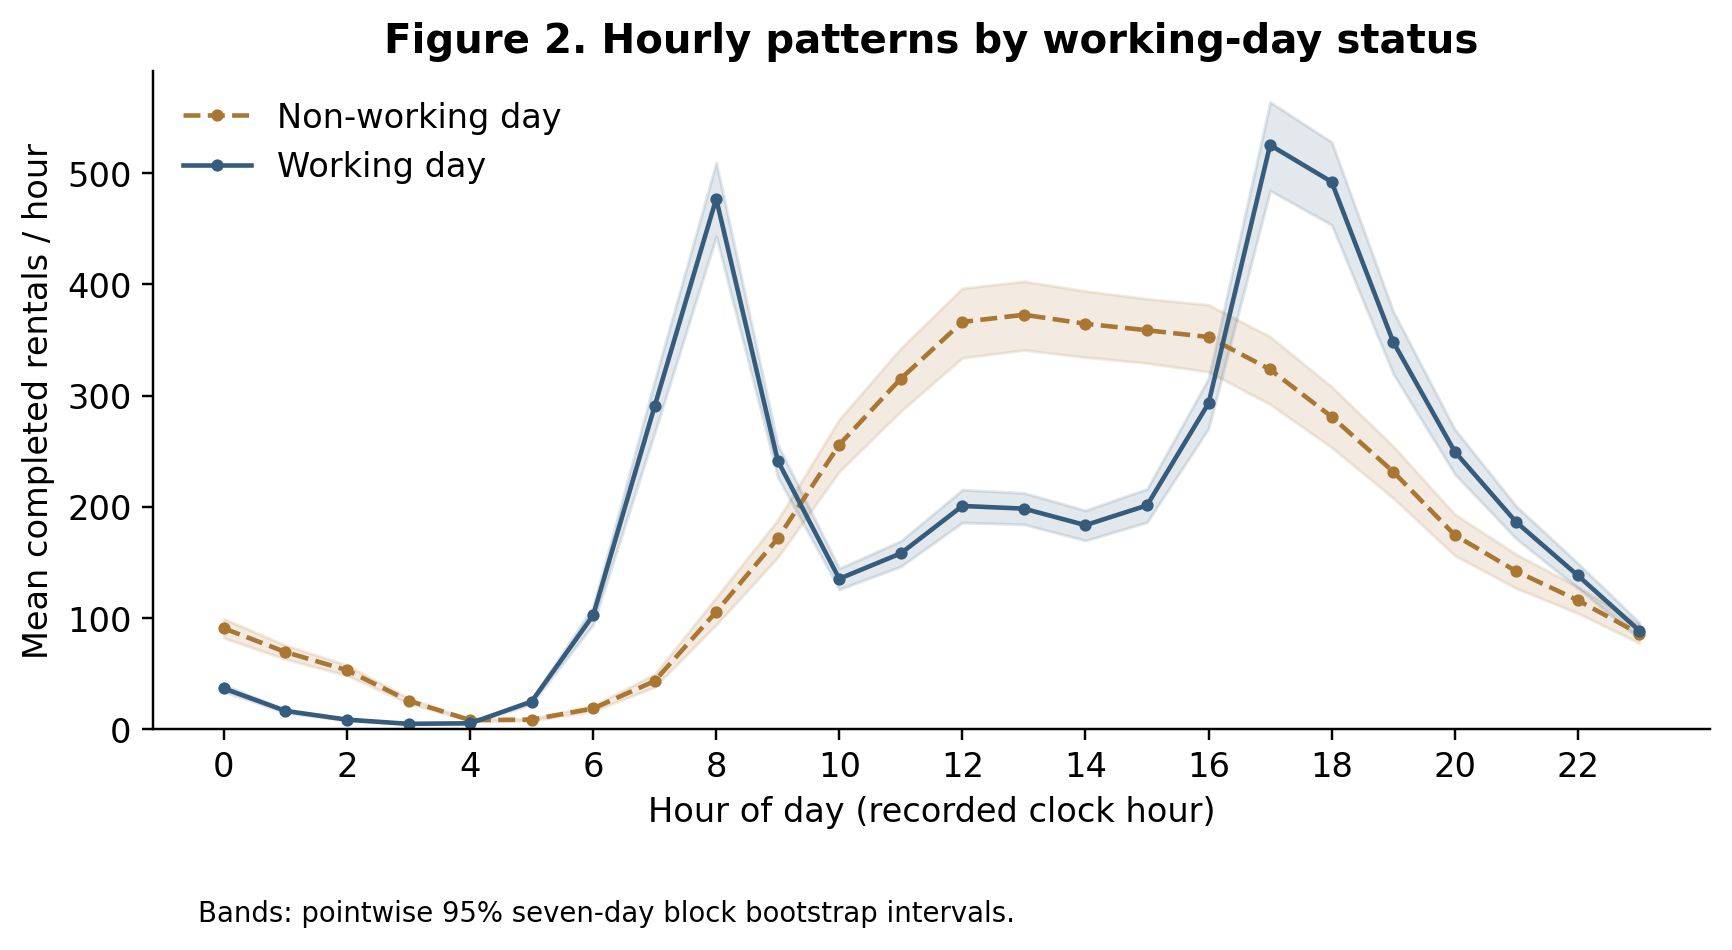

Working-day hourly means peak at 17:00 (525.29 rentals/hour); non-working-day means peak at 13:00 (372.73). The marginal working-minus-non-working mean difference is 11.80 rentals/hour (95% seven-day block interval 3.38 to 19.91). This marginal average hides distinct hourly profiles.

In [12]:
display(Image(filename=str(ROOT / 'results/figures/02_hour_workingday.png'), width=820))
display(Markdown(text['time']))

### Figure 3. Weather associations

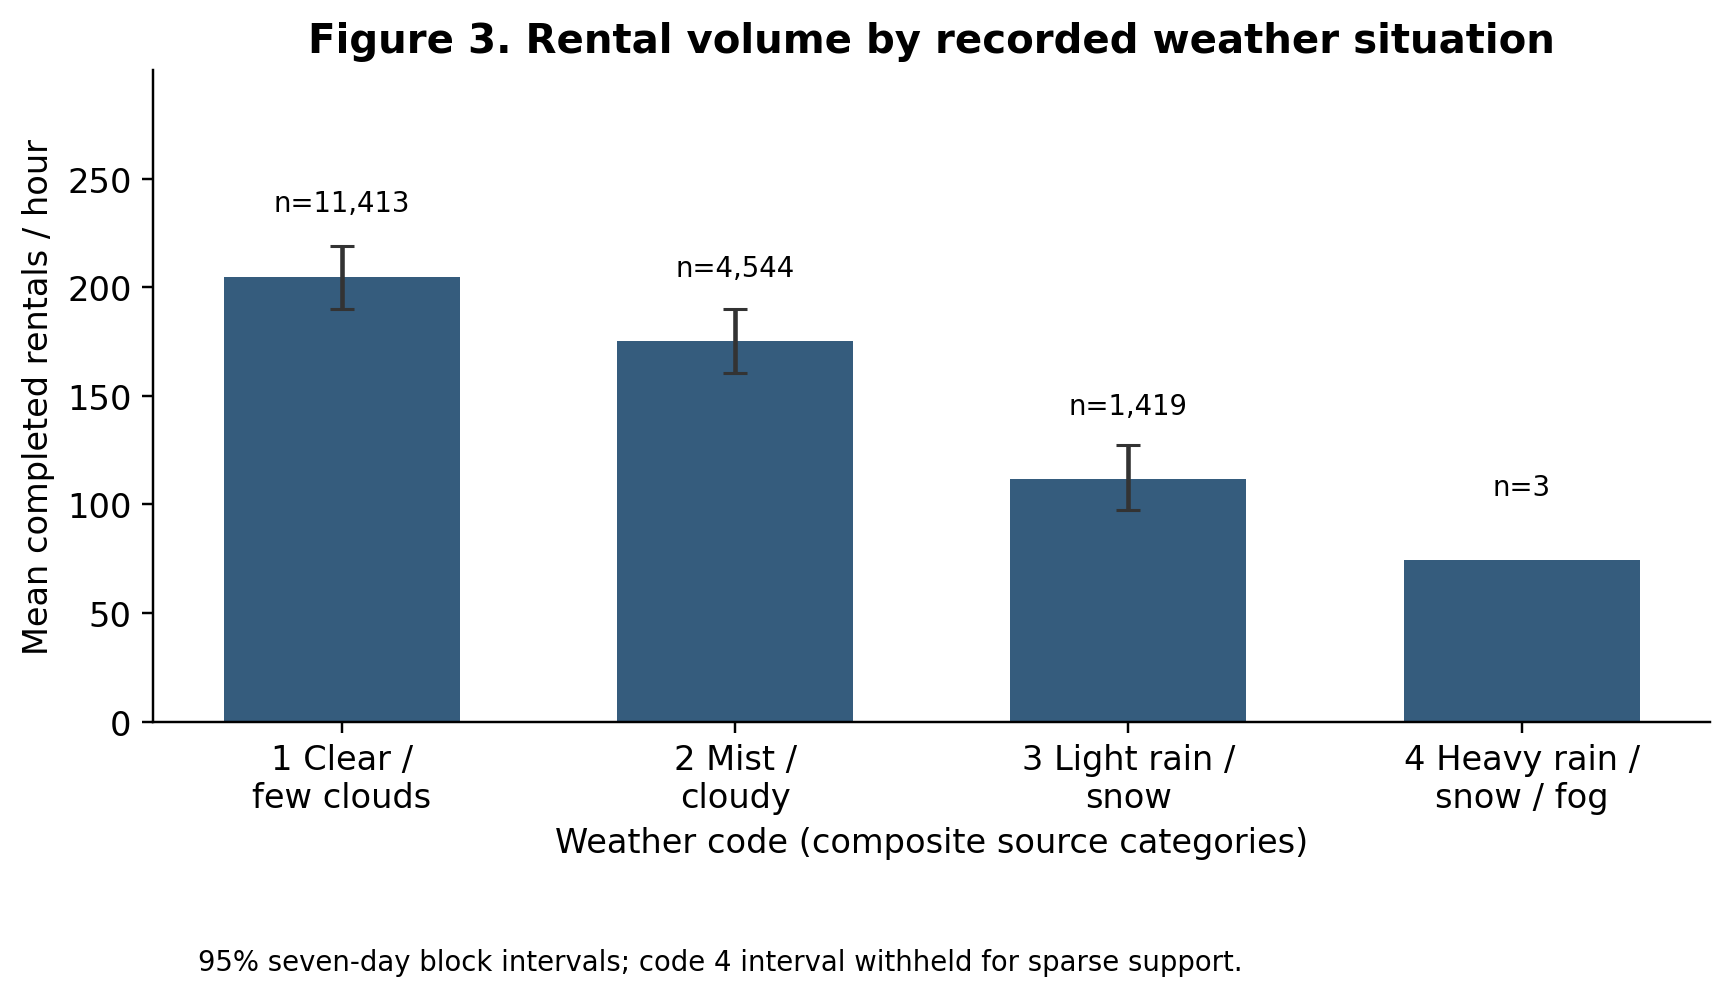

Observed mean rentals/hour are 204.87 for clear/few-cloud weather (n=11,413), 175.17 for mist/cloudy weather (n=4,544), and 111.58 for light-rain/snow weather (n=1,419). Weather code 4 has only 3 rows on 3 date(s); its descriptive mean is 74.33 and its interval is withheld. Marginal contrasts may reflect calendar and hour composition.

In [13]:
display(Image(filename=str(ROOT / 'results/figures/03_weather.png'), width=820))
display(Markdown(text['weather']))

### Figure 4. Working-day count distributions

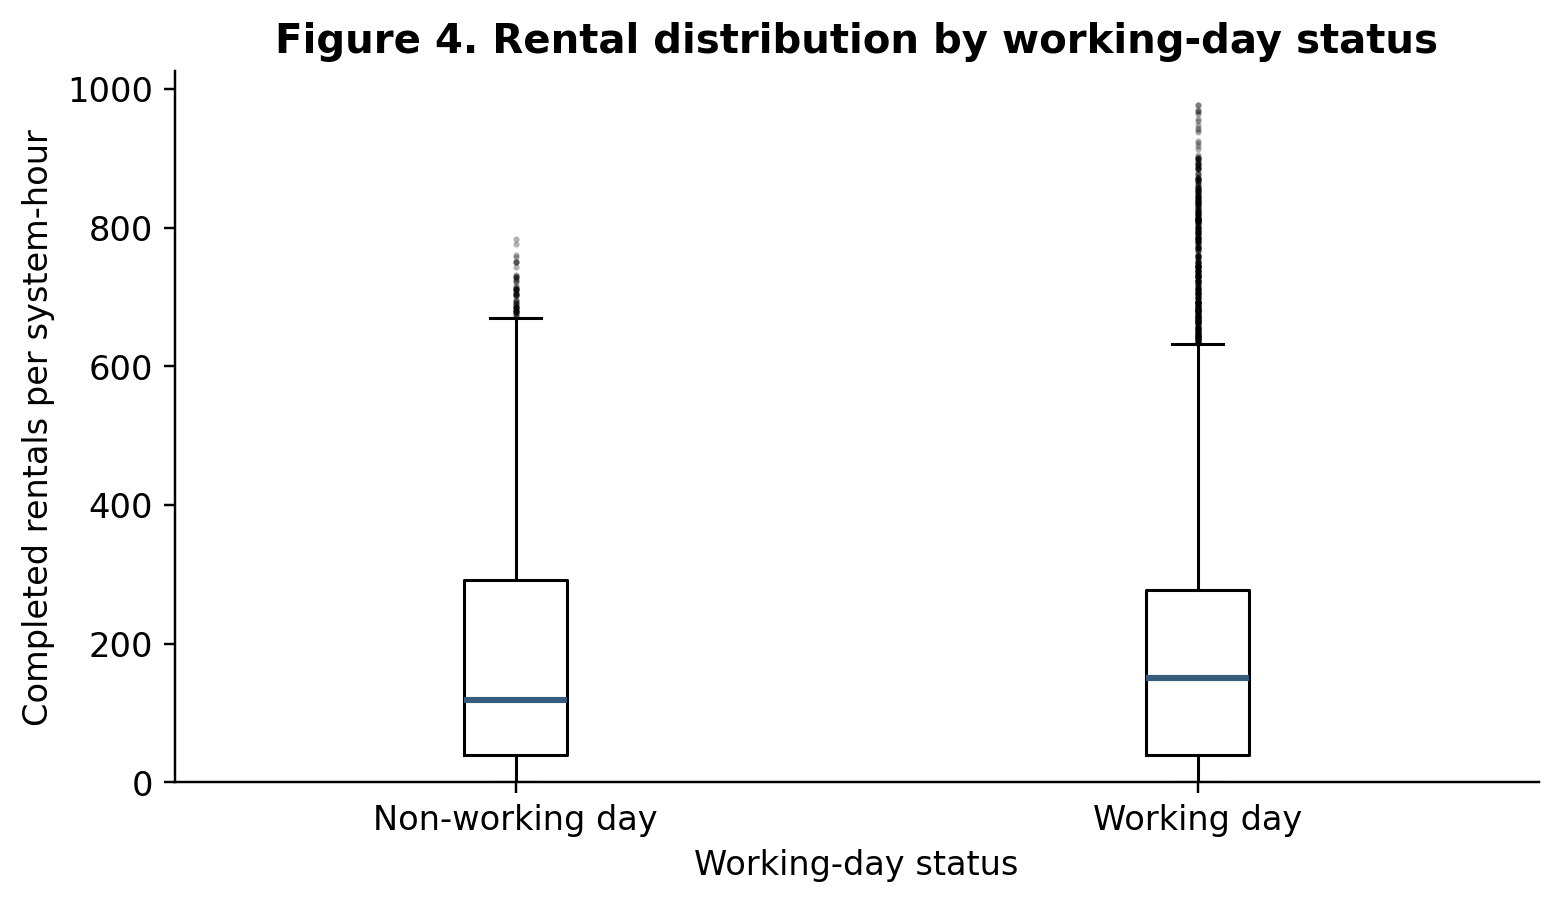

Working-day hourly means peak at 17:00 (525.29 rentals/hour); non-working-day means peak at 13:00 (372.73). The marginal working-minus-non-working mean difference is 11.80 rentals/hour (95% seven-day block interval 3.38 to 19.91). This marginal average hides distinct hourly profiles.

In [14]:
display(Image(filename=str(ROOT / 'results/figures/04_workingday_distribution.png'), width=820))
display(Markdown(text['time']))

### Figure 5. Hour x weather means

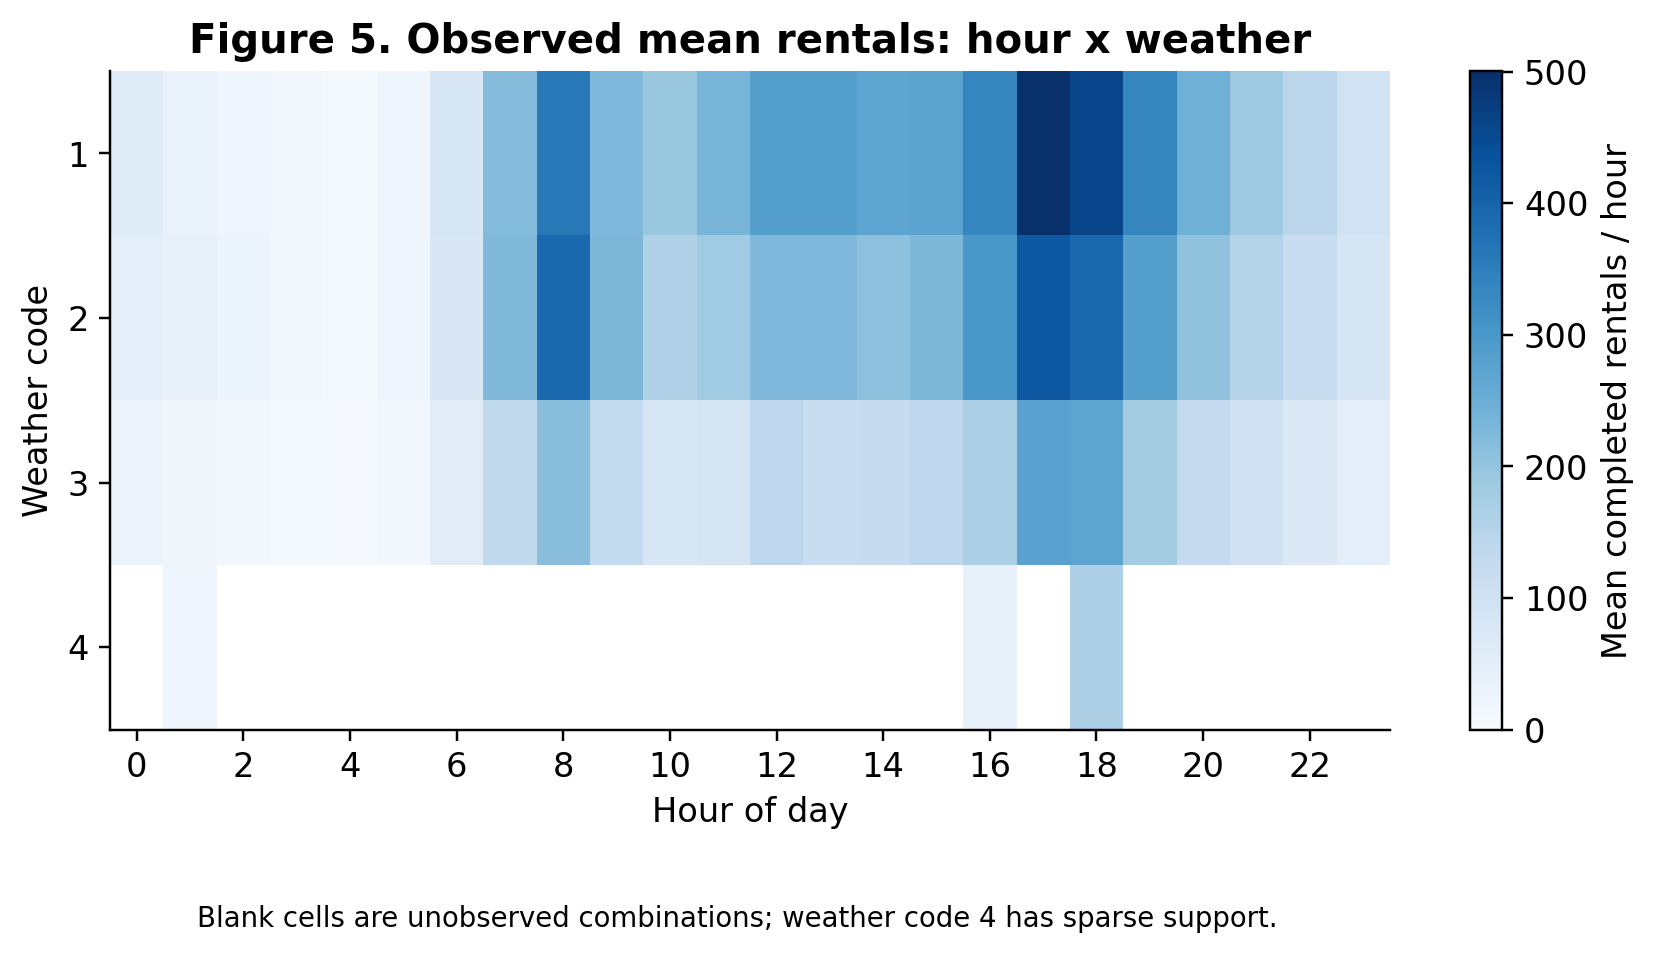

A nominal 24-hour-per-date grid contains 17,544 labels; 165 labels have no row. This is record-level incompleteness despite zero missing cells. Clock timezone, daylight-saving handling and omission reasons are undocumented. Absent hours are not assigned zero rentals; estimands are evaluated among observed rows.

In [15]:
display(Image(filename=str(ROOT / 'results/figures/05_hour_weather.png'), width=820))
display(Markdown(text['coverage']))

### Audit boxplots

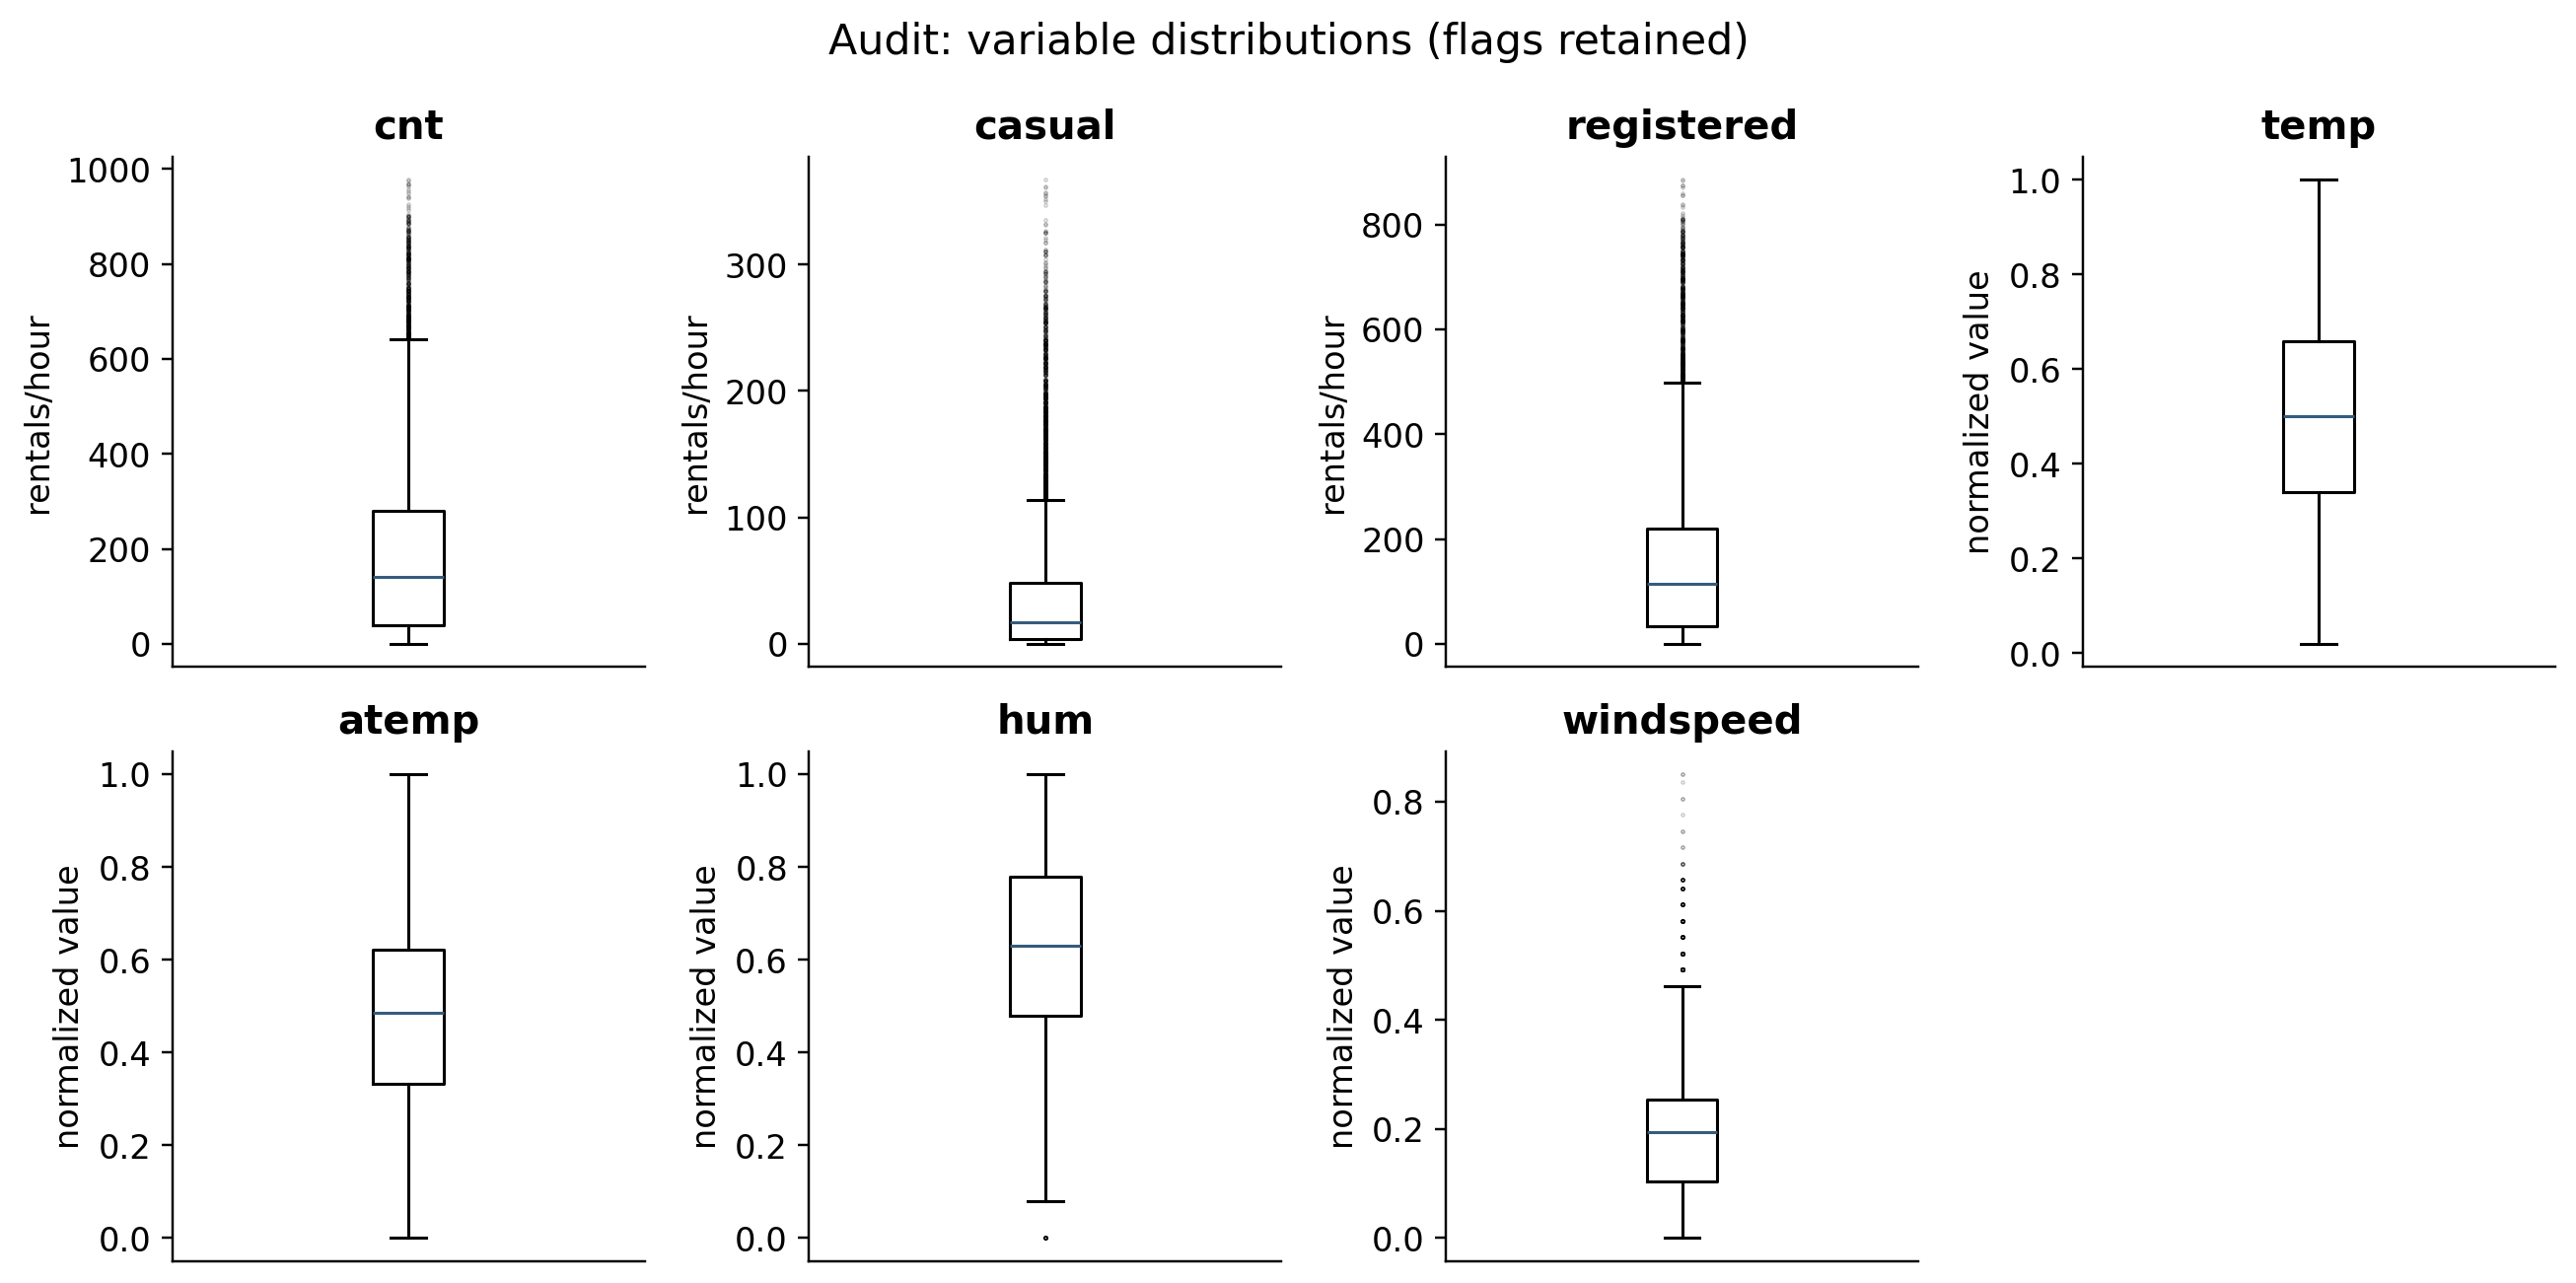

The observed count range is retained in full. Zero-count rows: 0; zero-humidity rows: 22; zero-wind rows: 2180. Zero humidity is a possible measurement concern, not an established missing code. IQR flags and the top 20 counts are saved with calendar/weather context. Statistically extreme rental counts are not automatically treated as data errors because they may represent genuine peak-demand periods.

In [16]:
display(Image(filename=str(ROOT / 'results/figures/06_audit_boxplots.png'), width=820))
display(Markdown(text['anomaly']))

### Audit histograms

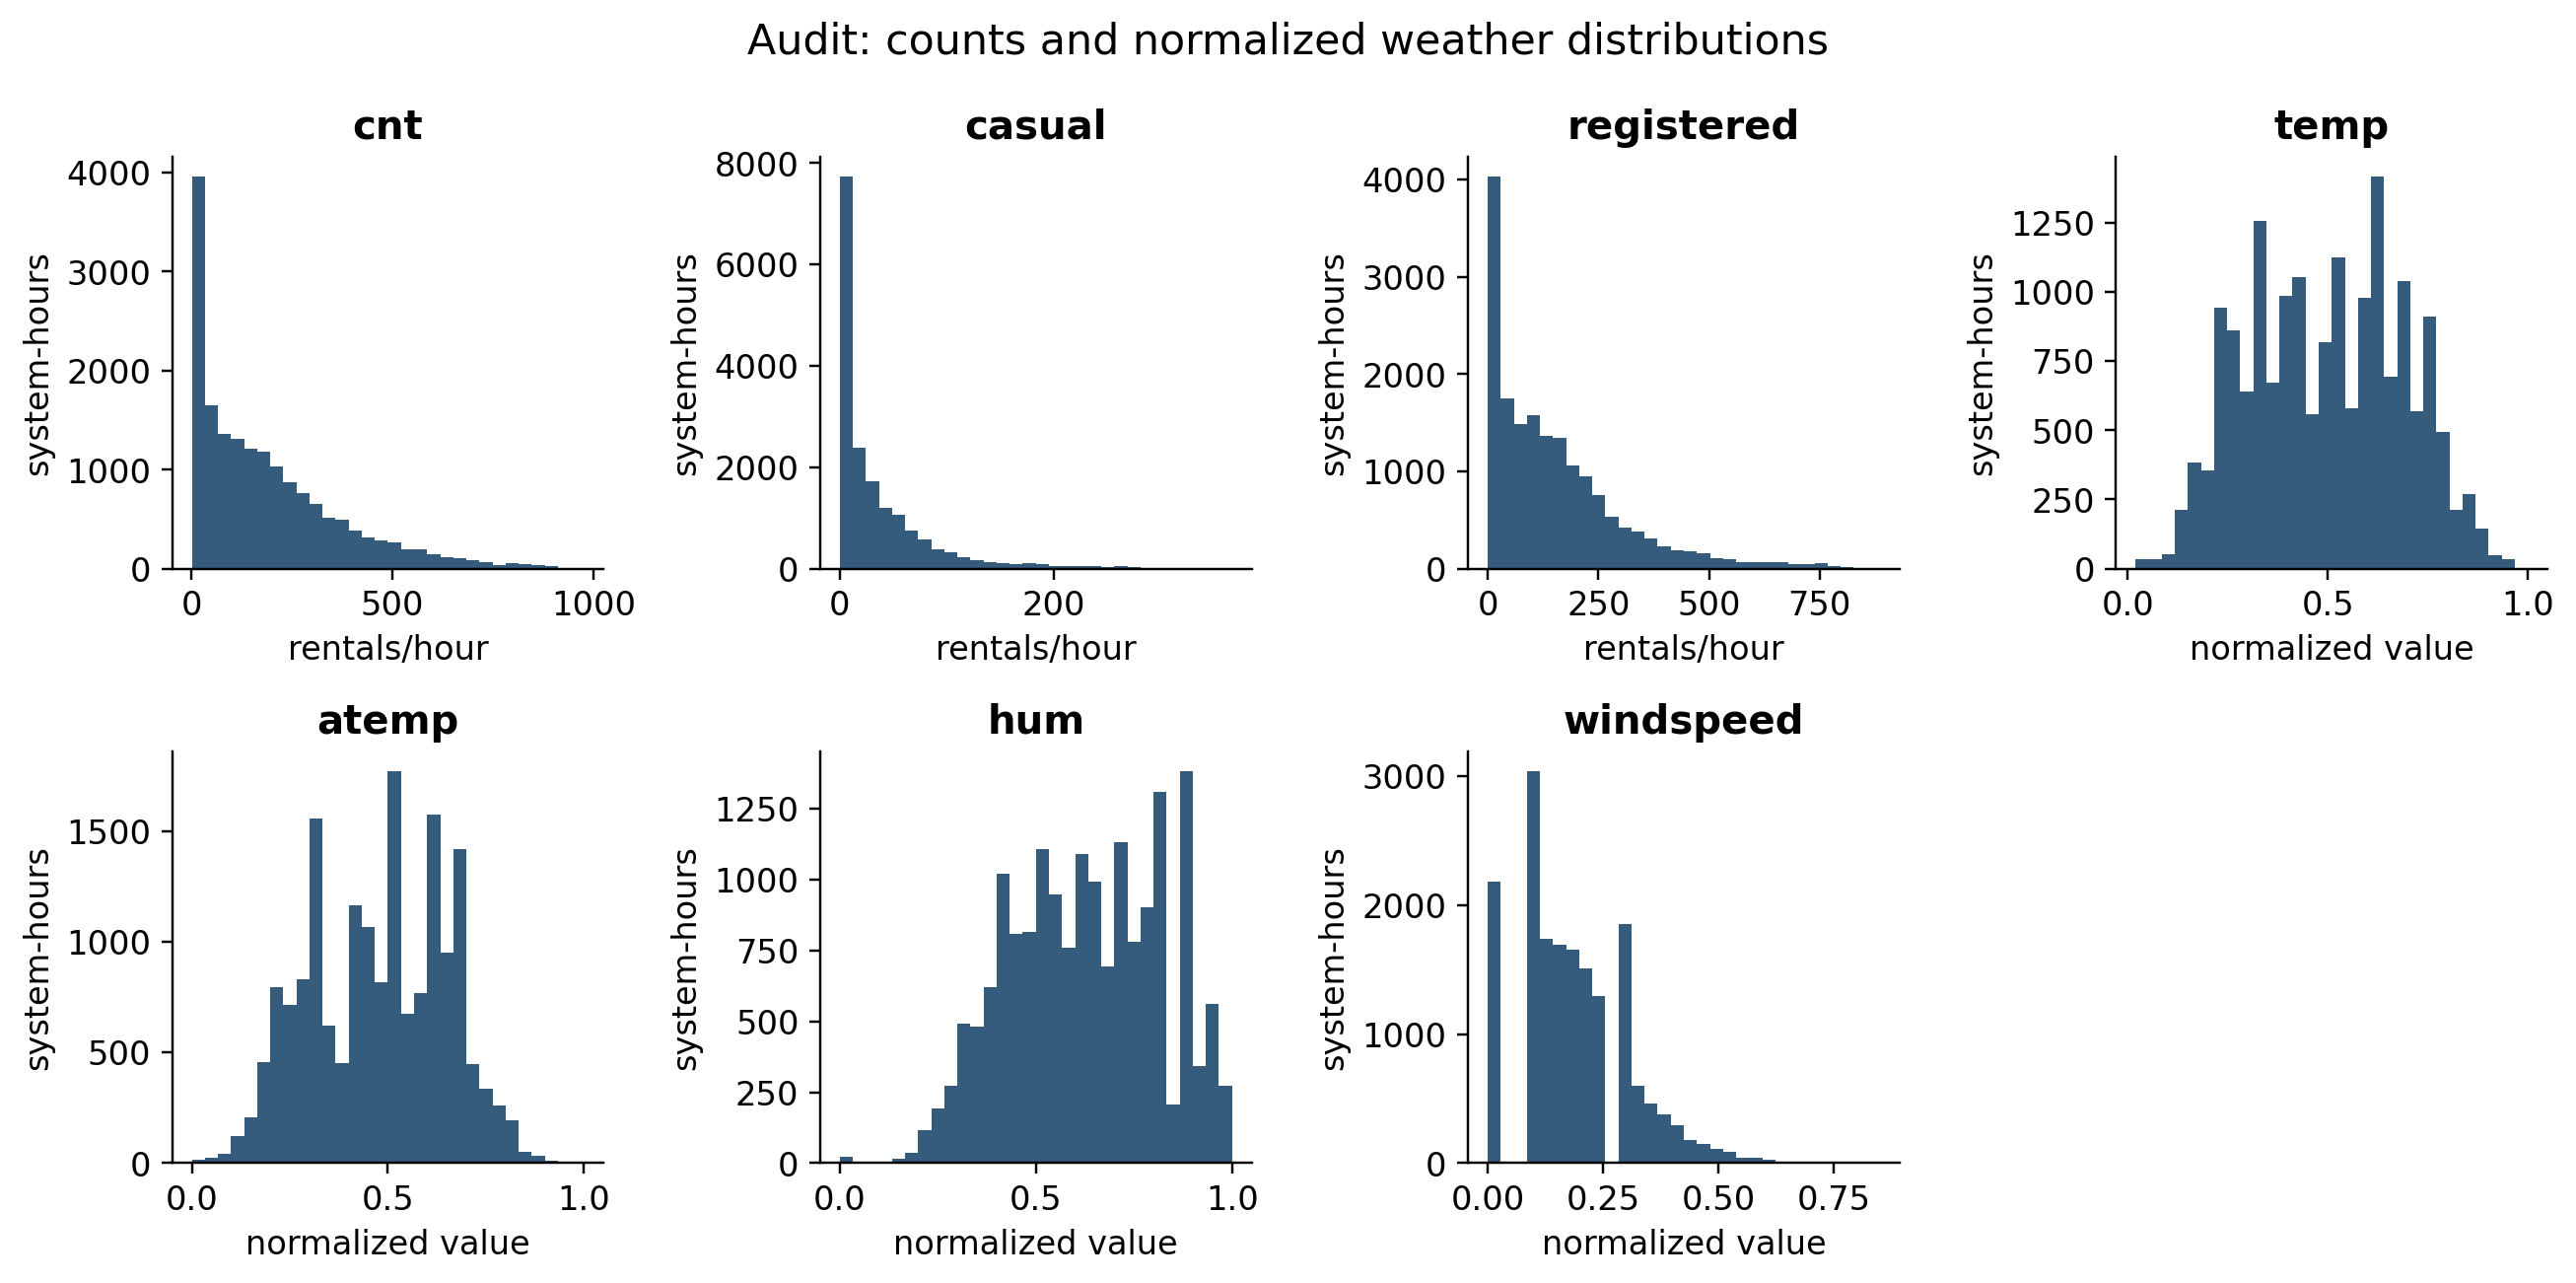

The observed count range is retained in full. Zero-count rows: 0; zero-humidity rows: 22; zero-wind rows: 2180. Zero humidity is a possible measurement concern, not an established missing code. IQR flags and the top 20 counts are saved with calendar/weather context. Statistically extreme rental counts are not automatically treated as data errors because they may represent genuine peak-demand periods.

In [17]:
display(Image(filename=str(ROOT / 'results/figures/07_audit_histograms.png'), width=820))
display(Markdown(text['anomaly']))

## 10. Measurement Counterexample
This is a conceptual example, not a reconstructed historical incident.

In [18]:
display(Markdown(text['measurement']))

Conceptual counterexample (not an event observed in these files): 200 people want a bike, only 100 bikes are available, and 100 rentals are completed. Observed cnt = 100 while latent demand is approximately 200. Bike availability, dock capacity, service outages and supply constraints are possible mechanisms. The CSV has no direct measures of unmet demand or these constraints; cnt measures completed rentals.

## 11. Bias and Limitations

In [19]:
display(Markdown(text['bias']))
display(Markdown(text['coverage']))
display(pd.read_csv(ROOT / 'results/humidity_zero_sensitivity.csv').round(3))

The temporal boundary is 2011-2012 and the system boundary is Capital Bikeshare in the Washington, D.C. area. Season, calendar, year and hour may confound marginal weather associations; system growth and serial dependence also limit statistical interpretation. Sparse weather-hour-workingday cells do not identify all conditional means reliably. Missing system-hours and measurement constraints limit representativeness. Historical patterns do not establish optimal rebalancing or current operating decisions.

A nominal 24-hour-per-date grid contains 17,544 labels; 165 labels have no row. This is record-level incompleteness despite zero missing cells. Clock timezone, daylight-saving handling and omission reasons are undocumented. Absent hours are not assigned zero rentals; estimands are evaluated among observed rows.

,weathersit,n,mean
0,1,11413,204.869
1,2,4542,175.211
2,3,1399,112.833
3,4,3,74.333


## 12. Prohibited Claims
### Claim 1
We must not claim that weather conditions causally determine bike rental demand based on this observational dataset. Weather is not randomly assigned and calendar/season/hour confounding is unaddressed.
### Claim 2
We must not generalize the observed relationships to all cities, all bike-sharing systems, or current populations. The sample is historical and system-specific.
### Claim 3
Observed rental counts should not be interpreted as a perfect measurement of unconstrained latent demand. Supply constraints and unfulfilled intentions are unmeasured.

## 13. Computed Takeaways and Conclusion

In [20]:
display(Markdown(text['audit']))
display(Markdown(text['weather']))
display(Markdown(text['time']))
display(Markdown(text['leakage']))
display(Markdown(text['conclusion']))

The raw hourly file contains 17,379 rows and 17 columns across 731 dates. The UCI metadata reports no missing values, and the independent programmatic audit found 0 missing cells across 17 columns. Exact duplicates: 0; duplicate date-hour keys: 0; failed range checks: 0; internal consistency failures: 0. The count identity holds for all 17,379 rows.

Observed mean rentals/hour are 204.87 for clear/few-cloud weather (n=11,413), 175.17 for mist/cloudy weather (n=4,544), and 111.58 for light-rain/snow weather (n=1,419). Weather code 4 has only 3 rows on 3 date(s); its descriptive mean is 74.33 and its interval is withheld. Marginal contrasts may reflect calendar and hour composition.

Working-day hourly means peak at 17:00 (525.29 rentals/hour); non-working-day means peak at 13:00 (372.73). The marginal working-minus-non-working mean difference is 11.80 rentals/hour (95% seven-day block interval 3.38 to 19.91). This marginal average hides distinct hourly profiles.

For prediction of cnt, casual and registered constitute deterministic target leakage: cnt = casual + registered on all 17,379 observed rows. Both components must be excluded from predictors. No model is trained. A future-facing model should use chronological evaluation and preprocessing fitted only on the training interval. Same-hour realized weather is potentially post-origin information for advance forecasts; feature timestamps are absent, so forecast availability cannot be certified.

The pinned data support a testable descriptive question about conditional mean completed rentals among observed 2011-2012 Capital Bikeshare system-hours. Hourly profiles differ by working-day status and rental volume differs across recorded weather categories. Data-level integrity passes do not remove source-document conflicts, absent-hour coverage, sparse cells, confounding or imperfect measurement. No causal, universal or optimal-dispatch claim follows.

## 14. Reproducibility and AI Use
Seed 42; all code lives in this repository and uses project-relative paths. Raw hashes are rechecked below. `python scripts/run_all.py` executes a fresh kernel, generates the formal ReportLab PDF and validates artifacts; see `docs/reproducibility.md` for exact environment versions and commands. Statistical results and prose are regenerated from shared canonical findings.

OpenAI Codex assisted with code, analysis, prose, plots, PDF and validation. No second human review is asserted. Implementation choices and the distinction between code checks and Codex visual review are disclosed in `docs/ai_use_log.md`.

In [21]:
from verify_data import verify
verify()
assert summary['row_count'] == len(df)
assert summary['missing_cells'] == int(df.isna().sum().sum())
assert summary['cnt_identity_failures'] == int((df.cnt != df.casual + df.registered).sum())
print('Notebook finished: all cells executed sequentially; source bytes unchanged.')

PASS: all pinned source hashes and sizes verified.
Notebook finished: all cells executed sequentially; source bytes unchanged.
